# Вероятность в нейронных сетях

## Модуль 5: PyTorch, autograd, вероятностные модели

В этом ноутбуке мы рассмотрим, как вероятность и статистика применяются в нейронных сетях.

### Содержание:
1. PyTorch тензоры и операции
2. Автоматическое дифференцирование (autograd)
3. Функции потерь как вероятностные модели
4. Dropout как байесовская аппроксимация
5. Введение в байесовские нейронные сети

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal, Bernoulli
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Проверка PyTorch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

PyTorch version: 2.12.1
CUDA available: False


## 1. PyTorch тензоры

**Тензор** — это многомерный массив, аналогичный numpy array, но с поддержкой GPU и автоматического дифференцирования.

### Основные операции:
- Создание тензоров
- Математические операции
- Индексирование и slicing
- Изменение формы (reshape)

### Связь с numpy:
- Тензоры можно конвертировать в numpy и обратно
- Большинство операций аналогичны numpy

In [2]:
# Пример: PyTorch тензоры

# Создание тензоров
x = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
y = torch.tensor([2.0, 4.0, 6.0, 8.0, 10.0])

print('PyTorch тензоры')
print('=' * 60)
print(f'x = {x}')
print(f'y = {y}')
print(f'\nТип: {x.dtype}')
print(f'Форма: {x.shape}')
print(f'Устройство: {x.device}')

# Математические операции
print(f'\nМатематические операции:')
print(f'x + y = {x + y}')
print(f'x * y = {x * y}')
print(f'x @ y = {x @ y}')  # Скалярное произведение
print(f'x.mean() = {x.mean()}')
print(f'x.std() = {x.std()}')

# Создание специальных тензоров
print(f'\nСпециальные тензоры:')
print(f'zeros: {torch.zeros(3)}')
print(f'ones: {torch.ones(3)}')
print(f'random: {torch.randn(3)}')
print(f'arange: {torch.arange(0, 10, 2)}')

# Матричные операции
A = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
B = torch.tensor([[5, 6], [7, 8]], dtype=torch.float32)

print(f'\nМатричные операции:')
print(f'A = \n{A}')
print(f'B = \n{B}')
print(f'A @ B = \n{A @ B}')
print(f'A.T = \n{A.T}')

PyTorch тензоры
x = tensor([1., 2., 3., 4., 5.])
y = tensor([ 2.,  4.,  6.,  8., 10.])

Тип: torch.float32
Форма: torch.Size([5])
Устройство: cpu

Математические операции:
x + y = tensor([ 3.,  6.,  9., 12., 15.])
x * y = tensor([ 2.,  8., 18., 32., 50.])
x @ y = 110.0
x.mean() = 3.0
x.std() = 1.5811388492584229

Специальные тензоры:
zeros: tensor([0., 0., 0.])
ones: tensor([1., 1., 1.])
random: tensor([-1.9421,  0.8501, -0.6764])
arange: tensor([0, 2, 4, 6, 8])

Матричные операции:
A = 
tensor([[1., 2.],
        [3., 4.]])
B = 
tensor([[5., 6.],
        [7., 8.]])
A @ B = 
tensor([[19., 22.],
        [43., 50.]])
A.T = 
tensor([[1., 3.],
        [2., 4.]])


## 2. Автоматическое дифференцирование (autograd)

**Autograd** автоматически вычисляет градиенты для тензоров.

### Как это работает:
1. PyTorch строит вычислительный граф
2. При вызове `.backward()` вычисляет градиенты
3. Градиенты сохраняются в атрибуте `.grad`

### Применение:
- Обучение нейронных сетей (backpropagation)
- Оптимизация функций
- Градиентный спуск

Автоматическое дифференцирование
Функция: y = x² + 3x + 1

x = 2.0
y = 11.0

Аналитическая производная: dy/dx = 2x + 3 = 7.0
Autograd: dy/dx = 7.0

Более сложный пример:

Функция: z = x²y + y³
x = 3.0, y = 4.0
z = 100.0

Аналитические производные:
  ∂z/∂x = 2xy = 24.0
  ∂z/∂y = x² + 3y² = 57.0

Autograd:
  ∂z/∂x = 24.0
  ∂z/∂y = 57.0


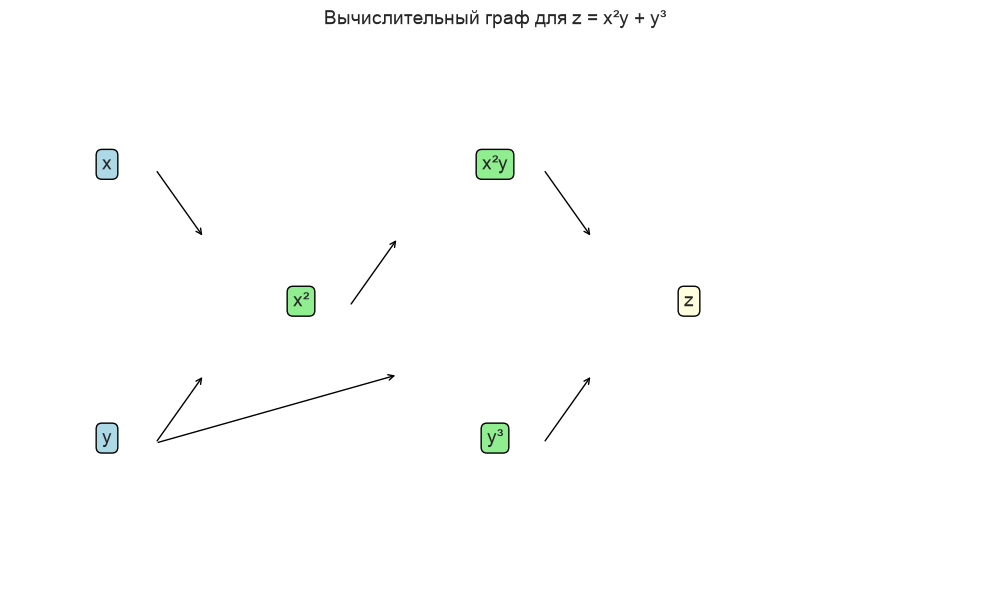

In [3]:
# Пример: Autograd

# Простая функция: y = x² + 3x + 1
x = torch.tensor(2.0, requires_grad=True)

y = x**2 + 3*x + 1

# Вычисление градиента
y.backward()

print('Автоматическое дифференцирование')
print('=' * 60)
print(f'Функция: y = x² + 3x + 1')
print(f'\nx = {x.item()}')
print(f'y = {y.item()}')
print(f'\nАналитическая производная: dy/dx = 2x + 3 = {2*x.item() + 3}')
print(f'Autograd: dy/dx = {x.grad.item()}')

# Более сложный пример
print(f'\n{"="*60}')
print('Более сложный пример:')

x = torch.tensor(3.0, requires_grad=True)
y = torch.tensor(4.0, requires_grad=True)

z = x**2 * y + y**3

z.backward()

print(f'\nФункция: z = x²y + y³')
print(f'x = {x.item()}, y = {y.item()}')
print(f'z = {z.item()}')
print(f'\nАналитические производные:')
print(f'  ∂z/∂x = 2xy = {2*x.item()*y.item()}')
print(f'  ∂z/∂y = x² + 3y² = {x.item()**2 + 3*y.item()**2}')
print(f'\nAutograd:')
print(f'  ∂z/∂x = {x.grad.item()}')
print(f'  ∂z/∂y = {y.grad.item()}')

# Визуализация вычислительного графа
fig, ax = plt.subplots(figsize=(10, 6))

# Простой вычислительный граф
ax.text(0.1, 0.8, 'x', fontsize=14, ha='center', bbox=dict(boxstyle='round', facecolor='lightblue'))
ax.text(0.1, 0.6, 'y', fontsize=14, ha='center', bbox=dict(boxstyle='round', facecolor='lightblue'))
ax.text(0.3, 0.7, 'x²', fontsize=14, ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen'))
ax.text(0.5, 0.8, 'x²y', fontsize=14, ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen'))
ax.text(0.5, 0.6, 'y³', fontsize=14, ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen'))
ax.text(0.7, 0.7, 'z', fontsize=14, ha='center', bbox=dict(boxstyle='round', facecolor='lightyellow'))

ax.annotate('', xy=(0.2, 0.75), xytext=(0.15, 0.8), arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.2, 0.65), xytext=(0.15, 0.6), arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.4, 0.75), xytext=(0.35, 0.7), arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.4, 0.65), xytext=(0.15, 0.6), arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.6, 0.75), xytext=(0.55, 0.8), arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.6, 0.65), xytext=(0.55, 0.6), arrowprops=dict(arrowstyle='->'))

ax.set_xlim(0, 1)
ax.set_ylim(0.5, 0.9)
ax.axis('off')
ax.set_title('Вычислительный граф для z = x²y + y³', fontsize=14)

plt.tight_layout()
plt.show()

## 3. Функции потерь как вероятностные модели

### MSE (Mean Squared Error) = Нормальное распределение:
$$\mathcal{L}_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

Это эквивалентно maximizing log-likelihood для $N(\hat{y}, \sigma^2)$:
$$\log P(y|x) = -\frac{1}{2\sigma^2} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 + \text{const}$$

### BCE (Binary Cross-Entropy) = Бернулли:
$$\mathcal{L}_{BCE} = -\frac{1}{N} \sum_{i=1}^{N} [y_i \log \hat{y}_i + (1 - y_i) \log(1 - \hat{y}_i)]$$

Это эквивалентно maximizing log-likelihood для Bernoulli($\hat{y}$).

### CCE (Categorical Cross-Entropy) = Категориальное распределение:
$$\mathcal{L}_{CCE} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{C} y_{ic} \log \hat{y}_{ic}$$

Эквивалентность MSE и Normal NLL
MSE loss: 0.0220
Normal NLL (σ=1): 0.9299

MSE = NLL / (2σ²) + const
0.0220 ≈ 0.9299 / 2 = 0.4650


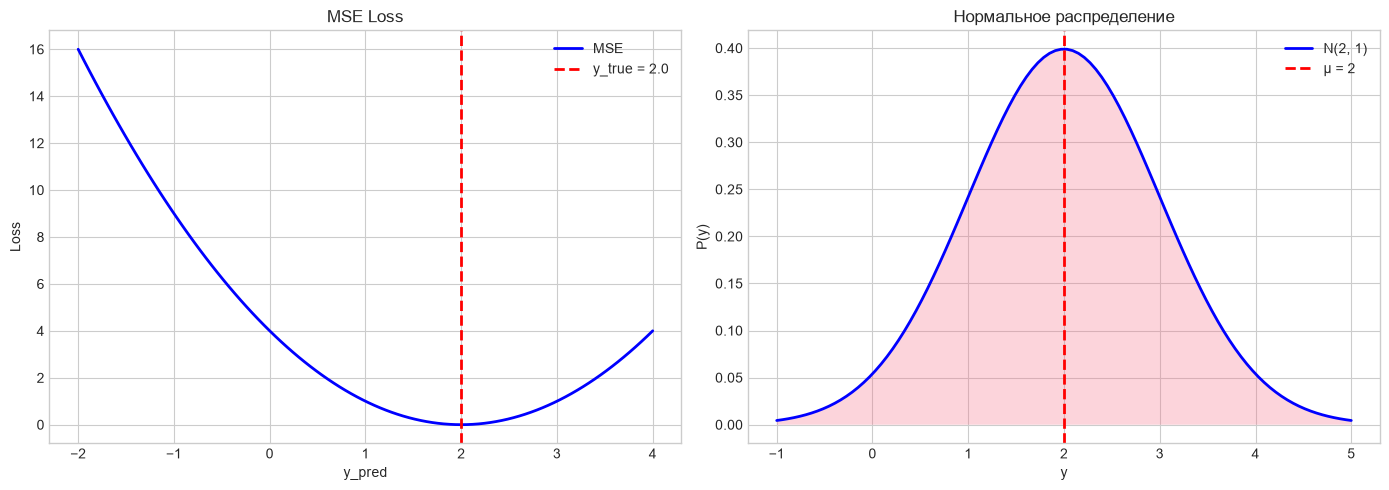

In [4]:
# Пример: Функции потерь как вероятностные модели

# MSE loss
def mse_loss(y_true, y_pred):
    return torch.mean((y_true - y_pred)**2)

# Normal log-likelihood
def normal_log_likelihood(y_true, y_pred, sigma=1.0):
    dist = Normal(y_pred, sigma)
    return -torch.mean(dist.log_prob(y_true))  # Negative log-likelihood

# Проверка эквивалентности
y_true = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
y_pred = torch.tensor([1.1, 2.2, 2.8, 4.1, 4.9])

mse = mse_loss(y_true, y_pred)
nll = normal_log_likelihood(y_true, y_pred, sigma=1.0)

print('Эквивалентность MSE и Normal NLL')
print('=' * 60)
print(f'MSE loss: {mse.item():.4f}')
print(f'Normal NLL (σ=1): {nll.item():.4f}')
print(f'\nMSE = NLL / (2σ²) + const')
print(f'{mse.item():.4f} ≈ {nll.item():.4f} / 2 = {nll.item()/2:.4f}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE loss surface
x_range = np.linspace(-2, 4, 100)
y_true_val = 2.0
mse_values = [(y_true_val - x)**2 for x in x_range]

axes[0].plot(x_range, mse_values, 'b-', linewidth=2, label='MSE')
axes[0].axvline(y_true_val, color='red', linestyle='--', linewidth=2, label=f'y_true = {y_true_val}')
axes[0].set_xlabel('y_pred')
axes[0].set_ylabel('Loss')
axes[0].set_title('MSE Loss')
axes[0].legend()

# Normal distribution
x_range = np.linspace(-1, 5, 100)
normal_dist = Normal(loc=2.0, scale=1.0)
pdf_values = torch.exp(normal_dist.log_prob(torch.tensor(x_range))).numpy()

axes[1].plot(x_range, pdf_values, 'b-', linewidth=2, label='N(2, 1)')
axes[1].axvline(2.0, color='red', linestyle='--', linewidth=2, label='μ = 2')
axes[1].fill_between(x_range, pdf_values, alpha=0.3)
axes[1].set_xlabel('y')
axes[1].set_ylabel('P(y)')
axes[1].set_title('Нормальное распределение')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Простая нейронная сеть на PyTorch

Создадим простую нейронную сеть для регрессии и покажем, как работает backpropagation.

Обучение нейронной сети
Истинные параметры: w = 3, b = 2
Обученные параметры: w = 2.6646, b = 1.9030
Финальная потеря: 0.3310


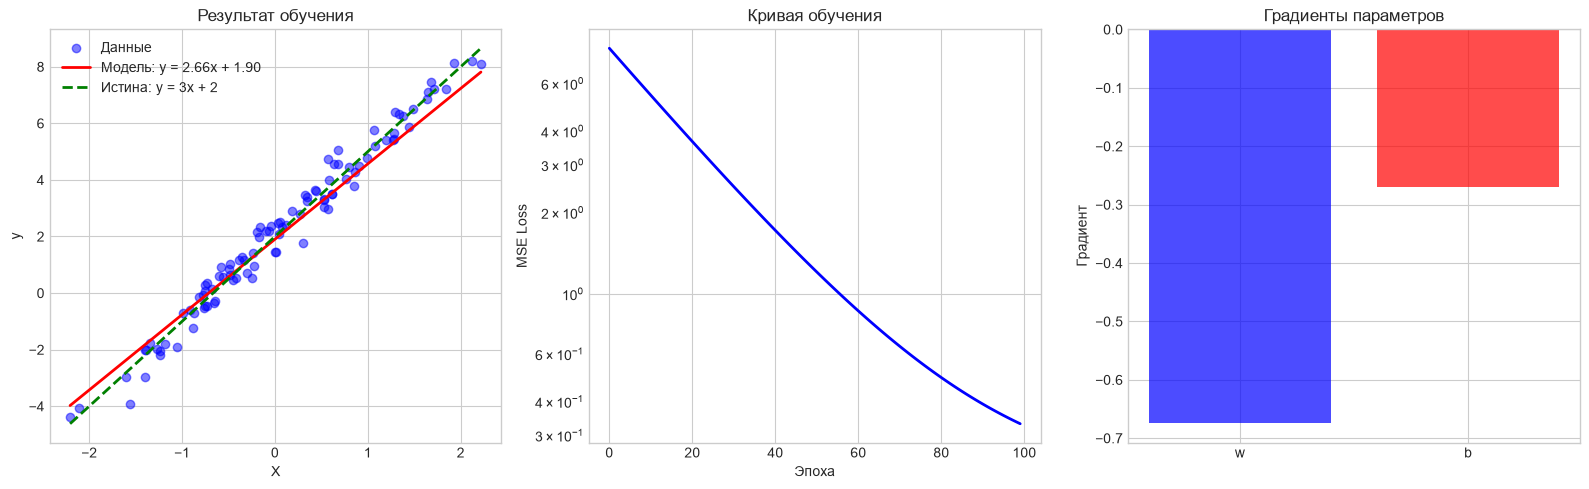

In [5]:
# Пример: Простая нейронная сеть
np.random.seed(42)
torch.manual_seed(42)

# Генерация данных
n_samples = 100
X = torch.randn(n_samples, 1)
y = 3 * X + 2 + torch.randn(n_samples, 1) * 0.5

# Определение модели
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.linear = nn.Linear(1, 1)
    
    def forward(self, x):
        return self.linear(x)

# Создание модели
model = SimpleNN()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Обучение
n_epochs = 100
losses = []

for epoch in range(n_epochs):
    # Forward pass
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

# Результаты
w = model.linear.weight.item()
b = model.linear.bias.item()

print('Обучение нейронной сети')
print('=' * 60)
print(f'Истинные параметры: w = 3, b = 2')
print(f'Обученные параметры: w = {w:.4f}, b = {b:.4f}')
print(f'Финальная потеря: {losses[-1]:.4f}')

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Данные и предсказание
axes[0].scatter(X.numpy(), y.numpy(), alpha=0.5, color='blue', label='Данные')
X_line = torch.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model(X_line).detach().numpy()
axes[0].plot(X_line.numpy(), y_line, 'r-', linewidth=2, label=f'Модель: y = {w:.2f}x + {b:.2f}')
axes[0].plot(X_line.numpy(), 3*X_line.numpy() + 2, 'g--', linewidth=2, label='Истина: y = 3x + 2')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].set_title('Результат обучения')
axes[0].legend()

# Потери
axes[1].plot(losses, 'b-', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Кривая обучения')
axes[1].set_yscale('log')

# Градиенты
model.zero_grad()
y_pred = model(X)
loss = criterion(y_pred, y)
loss.backward()

grad_w = model.linear.weight.grad.item()
grad_b = model.linear.bias.grad.item()

axes[2].bar(['w', 'b'], [grad_w, grad_b], color=['blue', 'red'], alpha=0.7)
axes[2].set_ylabel('Градиент')
axes[2].set_title('Градиенты параметров')
axes[2].axhline(0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## 5. Dropout как байесовская аппроксимация

**Dropout** — это метод регуляризации, который случайно "выключает" нейроны во время обучения.

### Байесовская интерпретация:
Dropout можно интерпретировать как аппроксимацию байесовского вывода:
- Каждое применение dropout — это сэмплирование из апостериорного распределения
- Усреднение предсказаний с разными dropout масками — это приближение апостериорного предсказания

### MC Dropout:
Используем dropout даже во время inference для получения uncertainty estimates.

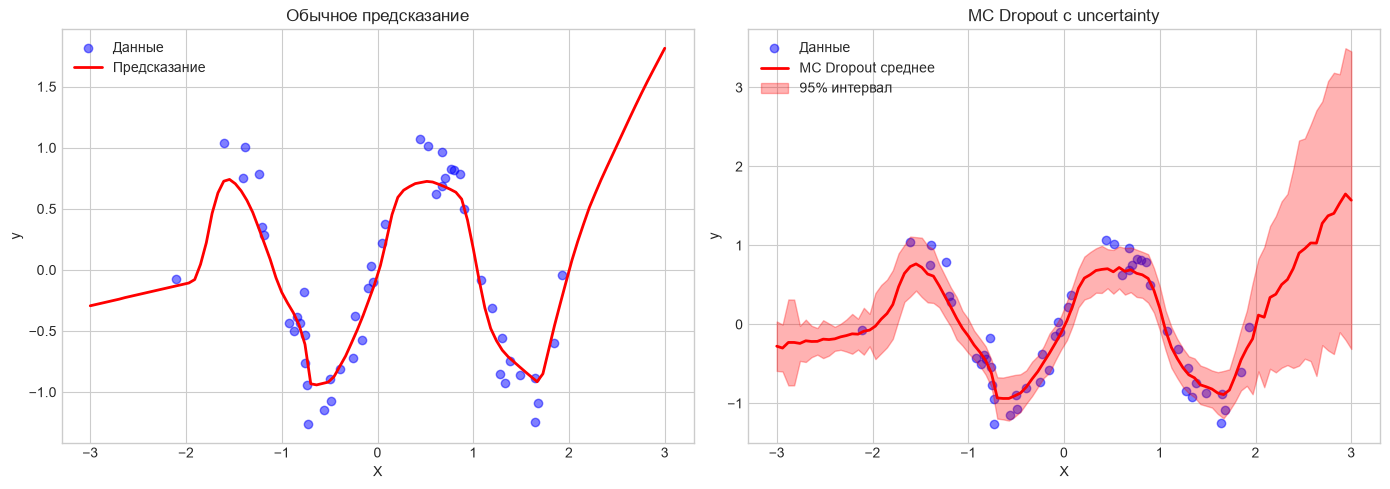

MC Dropout анализ uncertainty
Средняя неопределённость: 0.2334
Максимальная неопределённость: 0.9423
Минимальная неопределённость: 0.0760


In [6]:
# Пример: MC Dropout для uncertainty estimation
np.random.seed(42)
torch.manual_seed(42)

# Данные
n_samples = 50
X_train = torch.randn(n_samples, 1)
y_train = torch.sin(X_train * 3) + torch.randn(n_samples, 1) * 0.2

# Модель с Dropout
class DropoutNN(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super(DropoutNN, self).__init__()
        self.fc1 = nn.Linear(1, 64)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(64, 64)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(64, 1)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        return self.fc3(x)

# Обучение
model = DropoutNN(dropout_rate=0.2)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

n_epochs = 500
for epoch in range(n_epochs):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# MC Dropout inference
def mc_dropout_predict(model, X, n_samples=100):
    """MC Dropout предсказание с uncertainty"""
    model.train()  # Включаем dropout!
    predictions = []
    
    for _ in range(n_samples):
        with torch.no_grad():
            pred = model(X)
            predictions.append(pred.numpy())
    
    predictions = np.array(predictions)
    mean = np.mean(predictions, axis=0)
    std = np.std(predictions, axis=0)
    
    return mean, std

# Предсказания с uncertainty
X_test = torch.linspace(-3, 3, 100).reshape(-1, 1)
mean_pred, std_pred = mc_dropout_predict(model, X_test, n_samples=100)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Обычное предсказание
model.eval()
with torch.no_grad():
    y_test = model(X_test).numpy()

axes[0].scatter(X_train.numpy(), y_train.numpy(), alpha=0.5, color='blue', label='Данные')
axes[0].plot(X_test.numpy(), y_test, 'r-', linewidth=2, label='Предсказание')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].set_title('Обычное предсказание')
axes[0].legend()

# MC Dropout предсказание с uncertainty
axes[1].scatter(X_train.numpy(), y_train.numpy(), alpha=0.5, color='blue', label='Данные')
axes[1].plot(X_test.numpy(), mean_pred, 'r-', linewidth=2, label='MC Dropout среднее')
axes[1].fill_between(X_test.numpy().flatten(), 
                     (mean_pred - 2*std_pred).flatten(), 
                     (mean_pred + 2*std_pred).flatten(), 
                     alpha=0.3, color='red', label='95% интервал')
axes[1].set_xlabel('X')
axes[1].set_ylabel('y')
axes[1].set_title('MC Dropout с uncertainty')
axes[1].legend()

plt.tight_layout()
plt.show()

# Анализ uncertainty
print('MC Dropout анализ uncertainty')
print('=' * 60)
print(f'Средняя неопределённость: {np.mean(std_pred):.4f}')
print(f'Максимальная неопределённость: {np.max(std_pred):.4f}')
print(f'Минимальная неопределённость: {np.min(std_pred):.4f}')

## Упражнения

### Упражнение 1: Autograd
Вычислите градиенты функции $f(x, y) = x^2 y + xy^2$ в точке (2, 3) используя:
1. Autograd в PyTorch
2. Аналитически
3. Сравните результаты

### Упражнение 2: Функции потерь
1. Реализуйте Binary Cross-Entropy вручную
2. Сравните с `nn.BCELoss()`
3. Покажите, что BCE эквивалентна negative log-likelihood для Bernoulli

### Упражнение 3: Нейронная сеть
Создайте нейронную сеть для классификации:
- Вход: 2 признака
- Скрытые слои: 64, 32 нейрона
- Выход: 2 класса
- Используйте ReLU активацию

Обучите на синтетических данных и визуализируйте decision boundary.

### Упражнение 4: MC Dropout
Используя модель из упражнения 3:
1. Добавьте Dropout (p=0.3)
2. Обучите модель
3. Используйте MC Dropout для получения uncertainty estimates
4. Визуализируйте области высокой неопределённости

---

**Решения** можно найти в ноутбуке `solutions/14_Solutions.ipynb`